VelOT: Computing velocity field
  Basis: X_pca (15D)
  Cells: 5000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 14 window pairs across 3 clusters (skipped 0 small clusters)
  Window size: 300, step: 300

[2/4] Computing OT velocity...
  OT velocity computed: 4200 cells with velocity, 800 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
Found torch compatible version. Running on cpu device
    epoch 50/150: total=1.1864 reg=1.7884 smooth=0.0002 curl=0.0007
    epoch 100/150: total=1.0808 reg=1.6433 smooth=0.0002 curl=0.0005
    epoch 150/150: total=1.0522 reg=1.5939 smooth=0.0002 curl=0.0005
  Smoothing complete: final total=1.0522

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (5000 cells)
  Velocity projected to UMAP (5000 cells)

VelOT: Done.


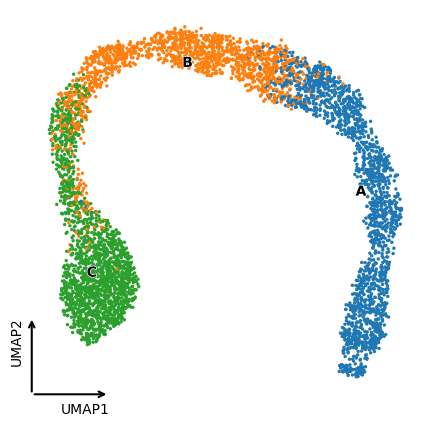

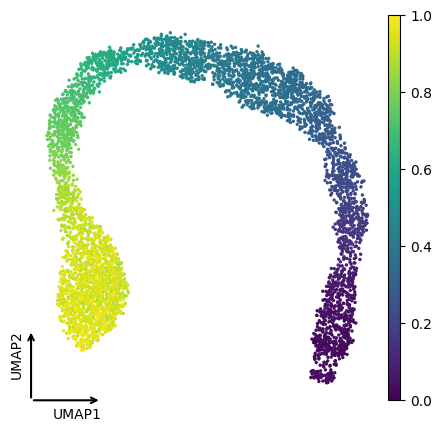

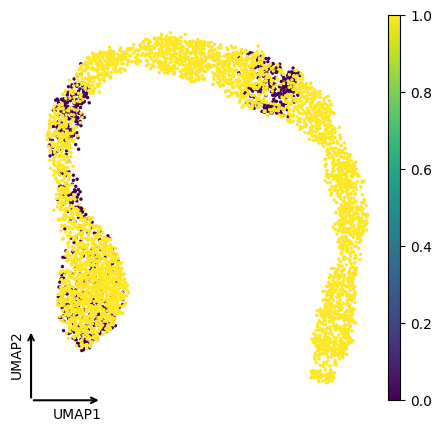

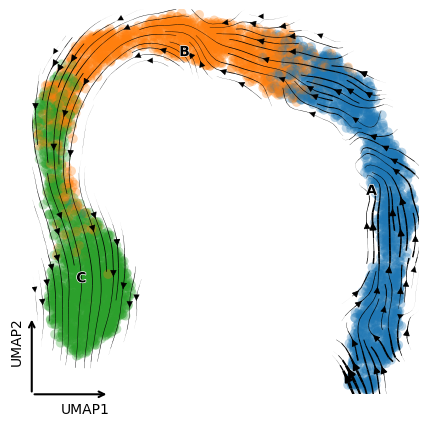

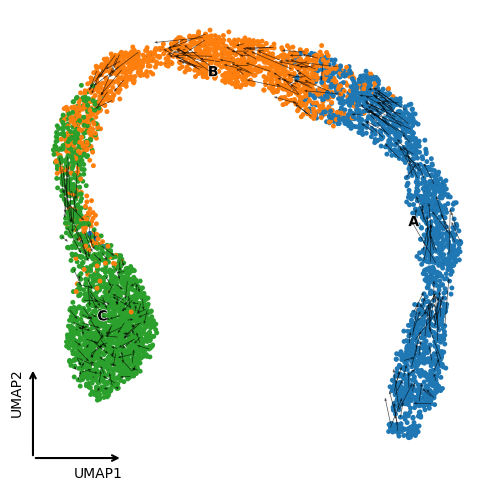

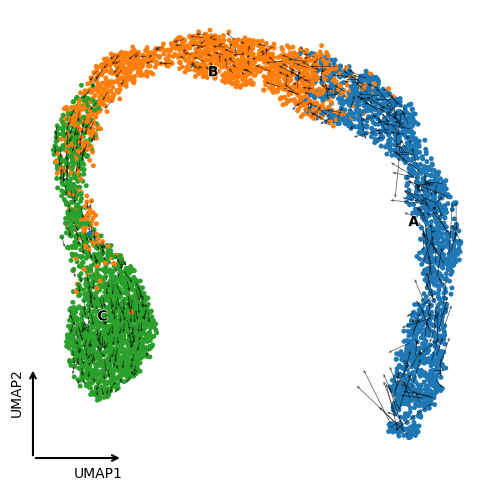

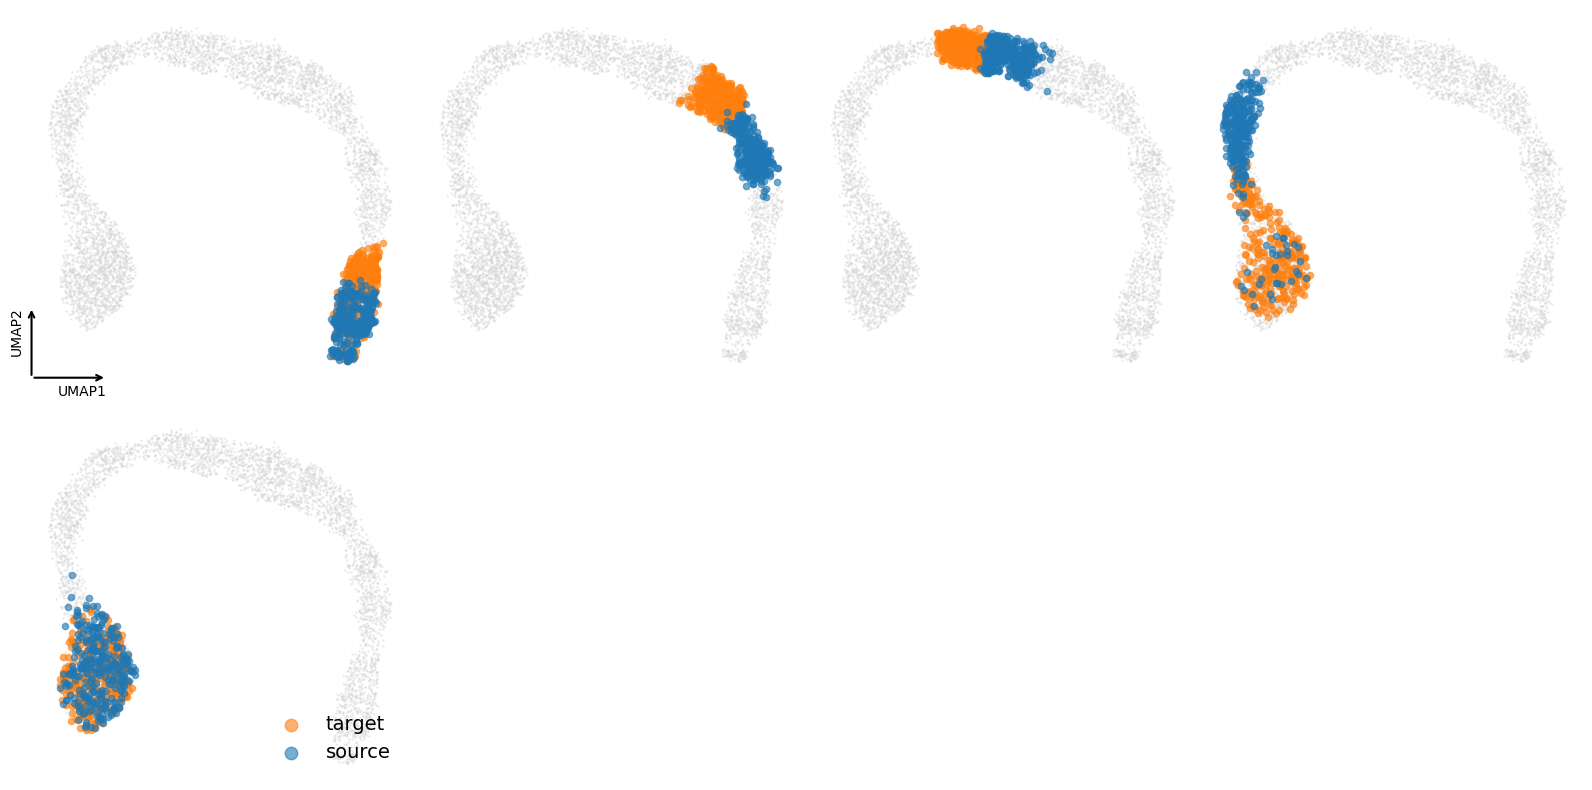

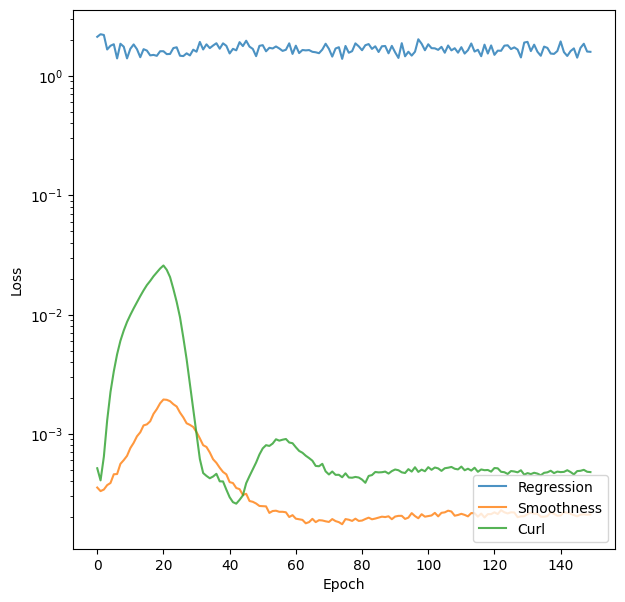

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.982):
                          A: 0.987
                          B: 0.978
                          C: 0.980

Inner-Cluster Coherence (median: 0.982):
                          A: 0.986
                          B: 0.979
                          C: 0.982

Cross-Boundary Correctness (mean: 0.857):
                A → B              : 0.901
                B → C              : 0.813


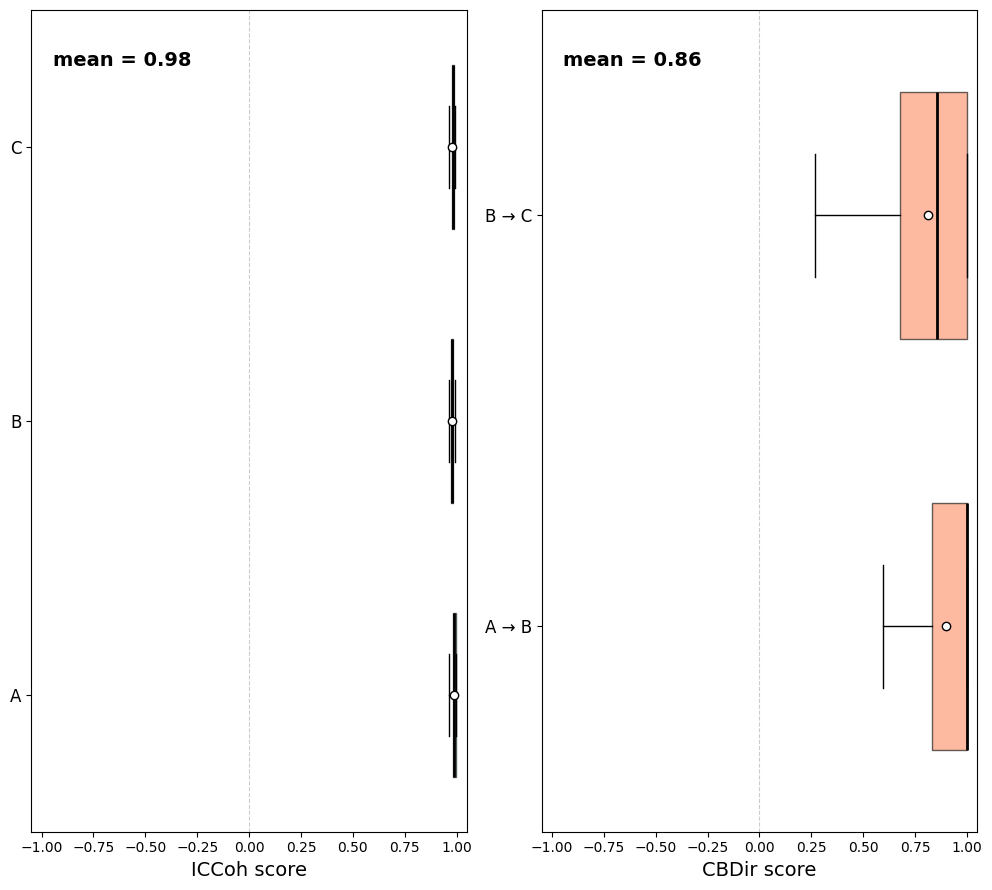

In [13]:
import velot
import scanpy as sc

figures_path = "/home/user/Documents/velot/article/figures/figure 3"
show = True
save = False
basis = "pca"
project_umap = True if basis == "pca" else False
clusters_key = "milestone"

# Load data
adata = sc.read("../article/data/Synthetic/synthetic_linear_processed.h5ad")

# Preprocess
velot.pp.pseudotime(adata, root_cluster="A", cluster_key=clusters_key)
adata.obs["milestone"] = adata.obs["milestone"].astype("category")
adata.obs["clusters_id"] = adata.obs["milestone"].cat.codes

adata.obsm["X_pca"] = adata.obsm["X_pca"][:, :15]

# Compute velocity (full pipeline)
velot.tl.velocity(
    adata=adata,
    basis=f"X_{basis}",
    smooth=True,
    n_clusters=None,
    window_size=300,
    overlap_fraction=0,
    tail_handling="drop", tail_threshold=10,
    spatial_key="clusters_id",
    reg=0.1, lambda_time=1, n_epochs=150, lambda_smooth=0.5, lambda_curl=0.5, lambda_divergence=0,
    project_umap=project_umap
)

# Visualize
velot.pl.dataset_overview_simple(adata, color=clusters_key, title="", figsize=(5,5), inframe=True, out_legend=False, show=show, save=save, save_path=f"{figures_path}/figure3_a.png")
velot.pl.dataset_overview_simple(adata, color="pseudotime", title="", show=show, save=save, save_path=f"{figures_path}/figure3_b.png")
velot.pl.dataset_overview_simple(adata, color="velot_confidence", title="", show=show, save=save, save_path=f"{figures_path}/figure3_c.png")
velot.pl.velocity_stream(adata, color=clusters_key, title=None, figsize=(5,5), show=show, save=save, save_path=f"{figures_path}/figure3_d.png", min_mass=0, density=2, cutoff_perc=0, linewidth=1.2)
velot.pl.velocity_quiver(adata, color=clusters_key, basis="umap", title="", subsample=500, figsize=(5,5), velocity_key=f"velot_velocity_raw_umap", show=show, save=save, save_path=f"{figures_path}/figure3_e.png")
velot.pl.velocity_quiver(adata, color=clusters_key, basis="umap", title="", subsample=500, figsize=(5,5), velocity_key=f"velot_velocity_umap", show=show, save=save, save_path=f"{figures_path}/figure3_f.png")
velot.pl.windows(adata, pairs_to_show=tuple([3*i for i in range(adata.uns["velot_windows"]["n_pairs"]) if 3*i<adata.uns["velot_windows"]["n_pairs"]]), figsize_per_panel=(4,4), show=show, save=save, save_path=f"{figures_path}/figure3_j.png")
velot.pl.training_curves_single(adata, figsize=(7,7), show=show, save=save, save_path=f"{figures_path}/figure3_g.png")

# Evaluate
edges = [
    ('A', 'B'),
    ('B', 'C')
]
results = velot.metrics.summary(adata, cluster_edges=edges, cluster_key=clusters_key, embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}")
velot.pl.metric_summary(results, orientation="horizontal", layout="row", figsize=(10,9), show=show, save=save, save_path=f"{figures_path}/figure3_h.png")

# # Trajectories using the continuous field with evolving pseudotime
# velot.tl.compute_trajectories(
#     adata,
#     basis=f"X_{basis}",
#     velocity_key=f"velot_velocity_{basis}",
#     direction="forward",
#     end_pseudotime=0.05,
#     use_network=True,
#     evolve_pseudotime=True,
#     n_trajectories=1,
#     cluster_key=clusters_key,
#     n_steps=300, step_size=1.5
# )
# velot.pl.trajectories(
#     adata, color=clusters_key, line_width=1.5, line_style="-", arrow_frequency=10, arrow_size=15,
#     basis="umap", show=show, save=save, save_path=f"{figures_path}/figure3_i.png")

# adata.write("/home/user/Documents/velot/article/data/Synthetic/cycle_velot.h5ad")

VelOT: Computing velocity field
  Basis: X_pca (30D)
  Cells: 5000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters_id': 5 clusters
  Built 32 window pairs across 5 clusters (skipped 0 small clusters)
  Window size: 150, step: 150

[2/4] Computing OT velocity...
  OT velocity computed: 4800 cells with velocity, 200 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
Found torch compatible version. Running on cpu device
    epoch 50/150: total=1.1595 reg=3.2612 smooth=0.0002 curl=0.0001
    epoch 100/150: total=1.1243 reg=3.3209 smooth=0.0001 curl=0.0000
    epoch 150/150: total=1.0504 reg=3.0790 smooth=0.0001 curl=0.0000
  Smoothing complete: final total=1.0504

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (5000 cells)
  Velocity projected to UMAP (5000 cells)

VelOT: Done.


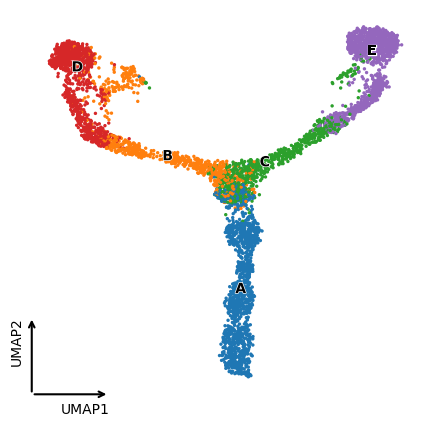

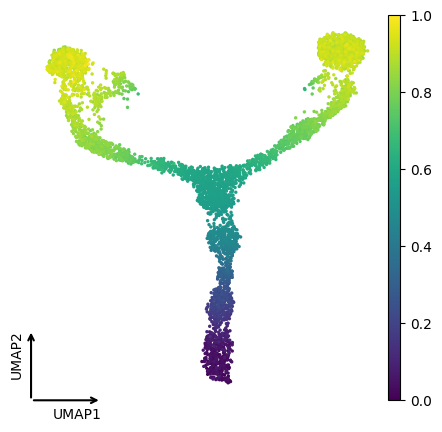

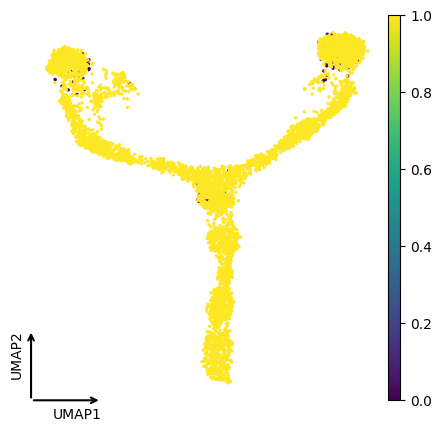

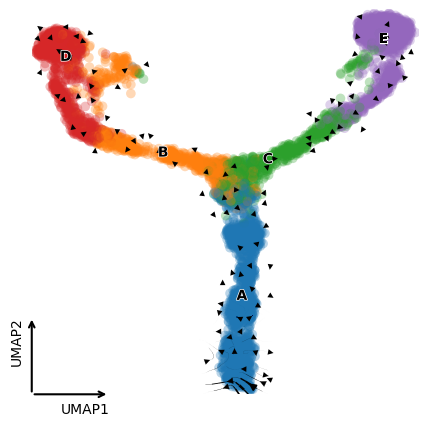

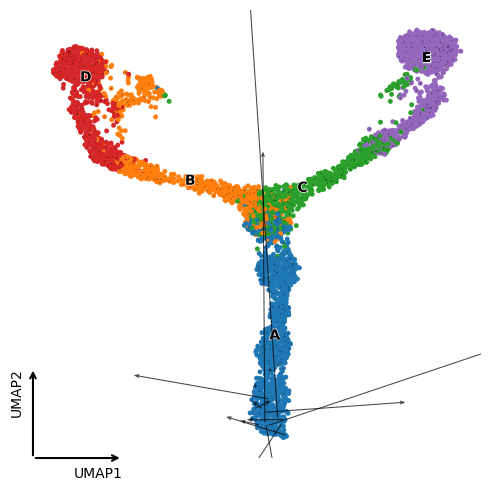

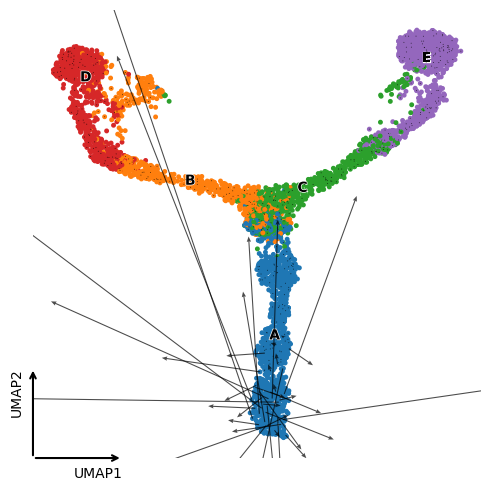

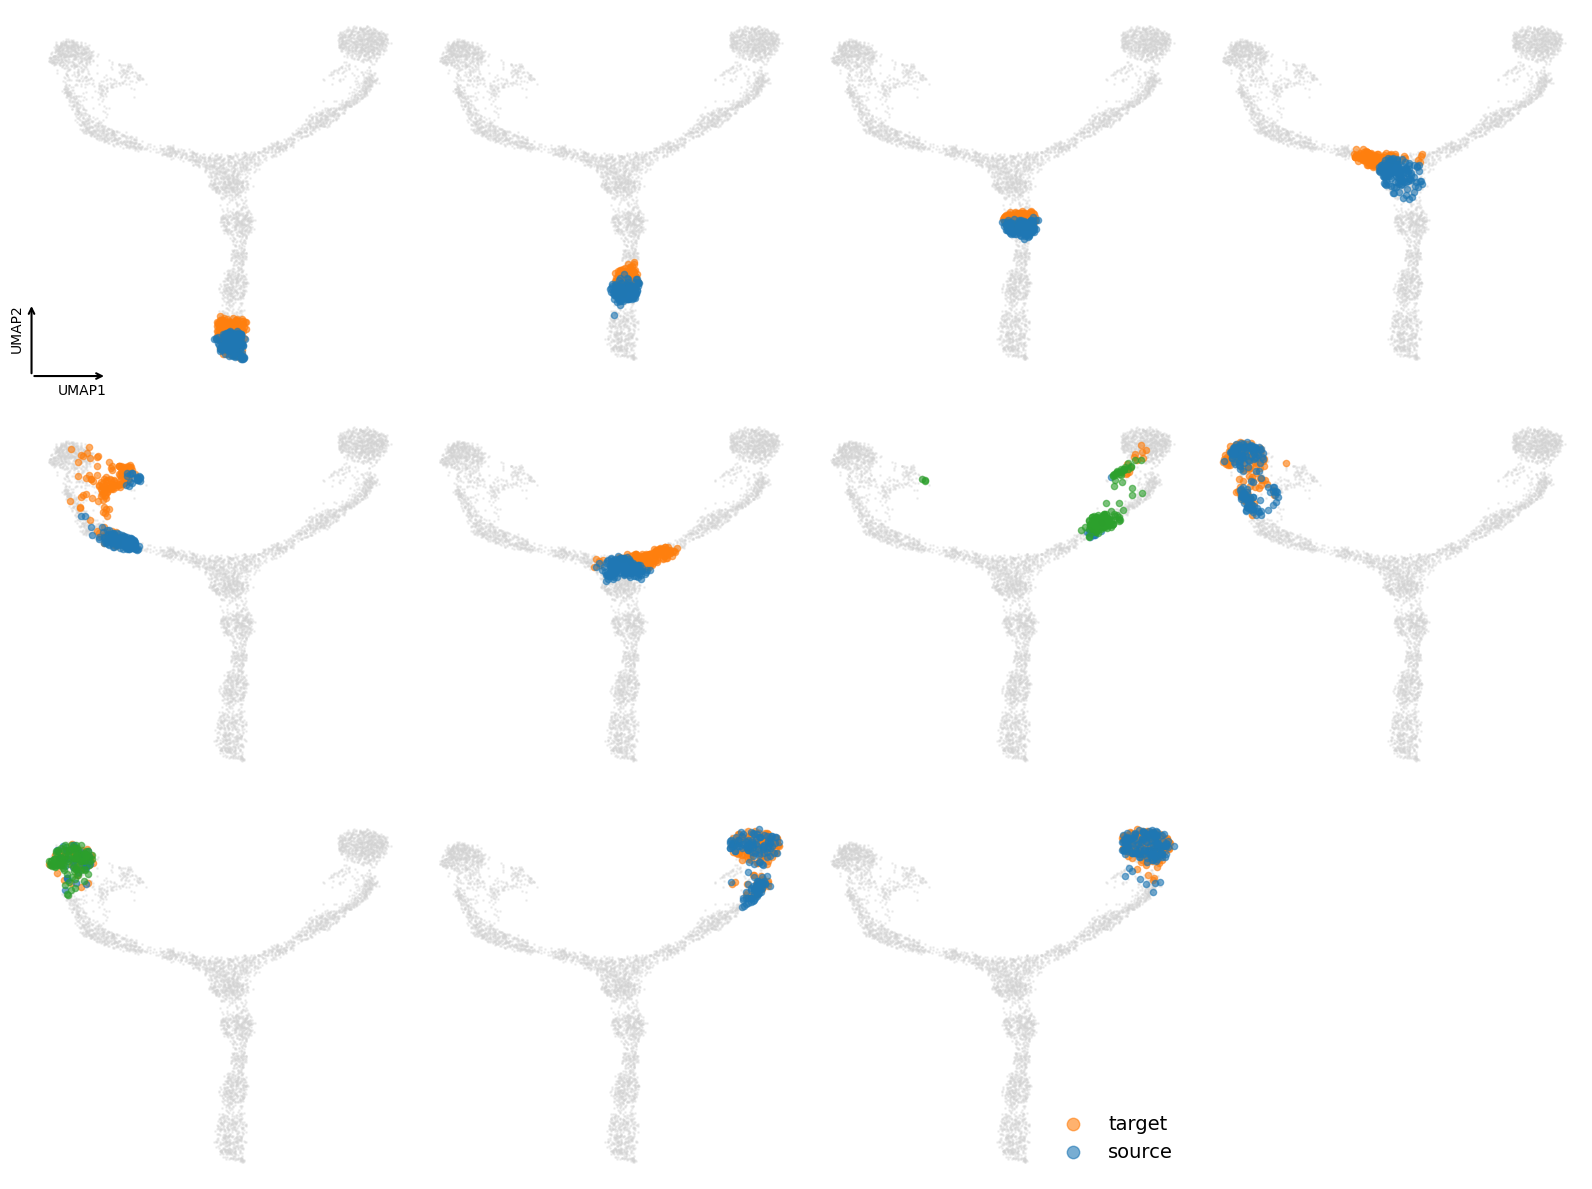

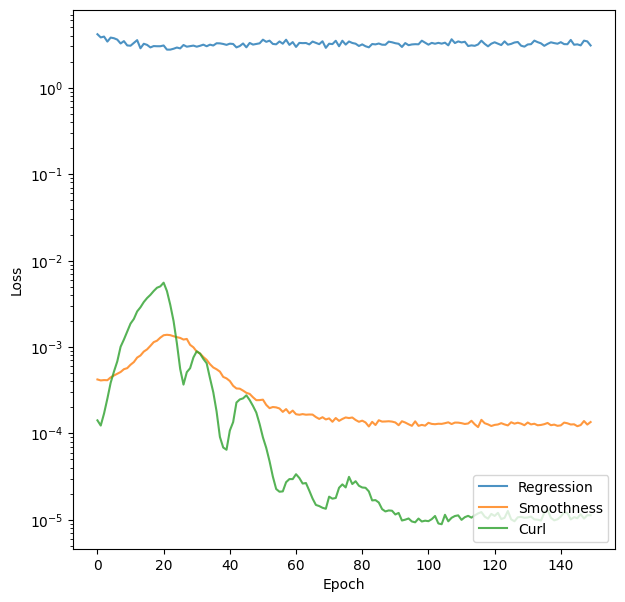

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.974):
                          A: 0.982
                          B: 0.962
                          C: 0.958
                          D: 0.990
                          E: 0.977

Inner-Cluster Coherence (median: 0.979):
                          A: 0.985
                          B: 0.975
                          C: 0.965
                          D: 0.991
                          E: 0.979

Cross-Boundary Correctness (mean: 0.907):
                A → B              : 0.957
                A → C              : 0.957
                B → D              : 0.787
                C → E              : 0.926


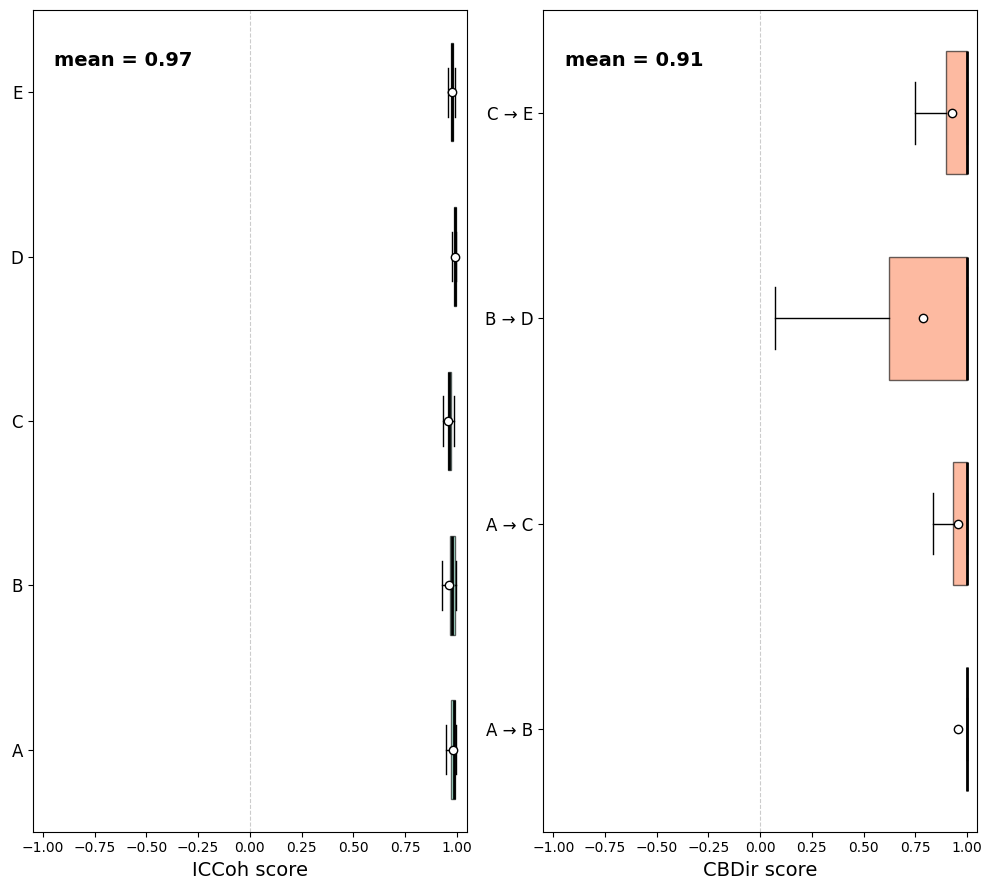

In [20]:
import velot
import scanpy as sc

figures_path = "/home/user/Documents/velot/article/figures/figure 3"
show = True
save = False
basis = "pca"
project_umap = True if basis == "pca" else False
clusters_key = "milestone"

# Load data
adata = sc.read("../article/data/Synthetic/synthetic_bifurcation_processed.h5ad")

# Preprocess
velot.pp.pseudotime(adata, root_cluster="A", root_cell=38)
adata.obs["milestone"] = adata.obs["milestone"].astype("category")
adata.obs["clusters_id"] = adata.obs["milestone"].cat.codes

adata.obsm["X_pca"] = adata.obsm["X_pca"][:, :30]

# Compute velocity (full pipeline)
velot.tl.velocity(
    adata=adata,
    basis=f"X_{basis}",
    smooth=True,
    n_clusters=3,
    window_size=150,
    overlap_fraction=0,
    tail_handling="drop", tail_threshold=10,
    spatial_key="clusters_id",
    reg=0.1, lambda_time=1, n_epochs=150, lambda_smooth=0.5, lambda_curl=0.5, lambda_divergence=0,
    project_umap=project_umap
)

# Visualize
velot.pl.dataset_overview_simple(adata, color=clusters_key, title="", figsize=(5,5), inframe=True, out_legend=False, show=show, save=save, save_path=f"{figures_path}/figure3_a.png")
velot.pl.dataset_overview_simple(adata, color="pseudotime", title="", show=show, save=save, save_path=f"{figures_path}/figure3_b.png")
velot.pl.dataset_overview_simple(adata, color="velot_confidence", title="", show=show, save=save, save_path=f"{figures_path}/figure3_c.png")
velot.pl.velocity_stream(adata, color=clusters_key, title=None, figsize=(5,5), show=show, save=save, save_path=f"{figures_path}/figure3_d.png", min_mass=0, density=2, cutoff_perc=0, linewidth=1.2)
velot.pl.velocity_quiver(adata, color=clusters_key, basis="umap", title="", subsample=500, figsize=(5,5), velocity_key=f"velot_velocity_raw_umap", show=show, save=save, save_path=f"{figures_path}/figure3_e.png")
velot.pl.velocity_quiver(adata, color=clusters_key, basis="umap", title="", subsample=500, figsize=(5,5), velocity_key=f"velot_velocity_umap", show=show, save=save, save_path=f"{figures_path}/figure3_f.png")
velot.pl.windows(adata, pairs_to_show=tuple([3*i for i in range(adata.uns["velot_windows"]["n_pairs"]) if 3*i<adata.uns["velot_windows"]["n_pairs"]]), figsize_per_panel=(4,4), show=show, save=save, save_path=f"{figures_path}/figure3_j.png")
velot.pl.training_curves_single(adata, figsize=(7,7), show=show, save=save, save_path=f"{figures_path}/figure3_g.png")

# Evaluate
edges = [
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('C', 'E')
]
results = velot.metrics.summary(adata, cluster_edges=edges, cluster_key=clusters_key, embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}")
velot.pl.metric_summary(results, orientation="horizontal", layout="row", figsize=(10,9), show=show, save=save, save_path=f"{figures_path}/figure3_h.png")

# # Trajectories using the continuous field with evolving pseudotime
# velot.tl.compute_trajectories(
#     adata,
#     basis=f"X_{basis}",
#     velocity_key=f"velot_velocity_{basis}",
#     direction="forward",
#     end_pseudotime=0.05,
#     use_network=True,
#     evolve_pseudotime=True,
#     n_trajectories=1,
#     cluster_key=clusters_key,
#     n_steps=300, step_size=1.5
# )
# velot.pl.trajectories(
#     adata, color=clusters_key, line_width=1.5, line_style="-", arrow_frequency=10, arrow_size=15,
#     basis="umap", show=show, save=save, save_path=f"{figures_path}/figure3_i.png")

# adata.write("/home/user/Documents/velot/article/data/Synthetic/cycle_velot.h5ad")

In [40]:
import numpy as np

V_umap = adata.obsm["velot_velocity_umap"]

mag = np.linalg.norm(V_umap, axis=1)

median = np.median(mag)

clip = 5 * median
# or 10 * median

scale = np.minimum(1, clip / (mag + 1e-8))

V_umap = V_umap * scale[:, None]

adata.obsm["velot_velocity_clipped_umap"] = V_umap

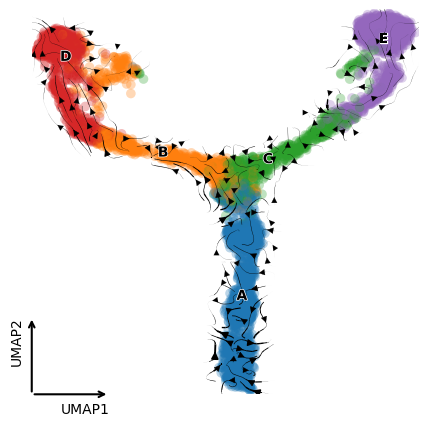

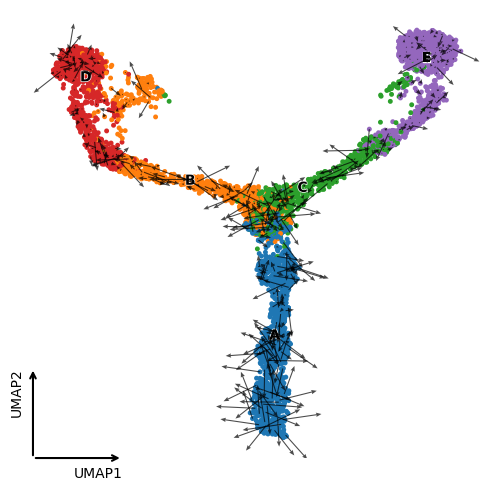

In [41]:
velot.pl.velocity_stream(adata, color=clusters_key, velocity_key="velot_velocity_clipped", title=None, figsize=(5,5), show=show, save=save, save_path=f"{figures_path}/figure3_d.png", min_mass=0, density=2, cutoff_perc=0, linewidth=1.2)
velot.pl.velocity_quiver(adata, color=clusters_key, basis="umap", title="", subsample=500, figsize=(5,5), velocity_key=f"velot_velocity_clipped_umap", show=show, save=save, save_path=f"{figures_path}/figure3_f.png")